In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
from google.colab import files
uploaded = files.upload()

Saving Airbnb_Open_Data.csv to Airbnb_Open_Data (1).csv


In [17]:
df = pd.read_csv("Airbnb_Open_Data (1).csv",low_memory=False)


In [18]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [20]:
#count the duplicate value
df.duplicated().value_counts()

,count
False,102058
True,541


In [21]:
#dropping the duplicated values
df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [22]:
#spelling mistake
df[df['neighbourhood group']=='brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,$116,4.0,167.0,24-06-2019,1.34,4.0,3.0,47.0,NaN,NaN


In [25]:
import pandas as pd

# Drop columns with high null or insufficient data
df.drop(['house_rules', 'license'], axis=1, inplace=True)

# Remove dollar signs
df['price'] = df['price'].str.replace('$', '', regex=False)
df['service fee'] = df['service fee'].str.replace('$', '', regex=False)

# Remove commas
df['price'] = df['price'].str.replace(',', '', regex=False)
df['service fee'] = df['service fee'].str.replace(',', '', regex=False)

# Rename columns to include $ sign
df.rename(columns={'price': '$price', 'service fee': '$service fee'}, inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Fix datatypes
df['$price'] = df['$price'].astype(float)
df['$service fee'] = df['$service fee'].astype(float)
df['id'] = df['id'].astype(int)
df['host id'] = df['host id'].astype(int)
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
df['Construction year'] = df['Construction year'].astype(int)

# Spelling correction
df['neighbourhood group'] = df['neighbourhood group'].replace('brookln', 'Brooklyn')

# Remove outliers in availability (shouldn’t exceed 365 days)
df = df.drop(df[df['availability 365'] > 365].index)

# Checking result
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 81263 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              81263 non-null  int64         
 1   NAME                            81263 non-null  object        
 2   host id                         81263 non-null  int64         
 3   host_identity_verified          81263 non-null  object        
 4   host name                       81263 non-null  object        
 5   neighbourhood group             81263 non-null  object        
 6   neighbourhood                   81263 non-null  object        
 7   lat                             81263 non-null  float64       
 8   long                            81263 non-null  float64       
 9   country                         81263 non-null  object        
 10  country code                    81263 non-null  object        
 11  instan

/tmp/ipython-input-243381010.py:25: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review'] = pd.to_datetime(df['last review'], errors='coerce')


In [26]:
df.duplicated().value_counts()

,count
False,81263


In [27]:
df.describe()

,id,host id,lat,long,Construction year,$price,$service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,8.126300e+04,8.126300e+04,81263.000000,81263.000000,81263.000000,81263.000000,81263.000000,81263.000000,81263.000000,81263,81263.000000,81263.000000,81263.000000,81263.000000
mean,3.004764e+07,4.917566e+10,40.727260,-73.948261,2012.490666,626.626177,125.326274,7.417349,32.025190,2019-06-21 04:15:15.604887808,1.391148,3.286391,7.106543,135.031847
min,1.001254e+06,1.236005e+08,40.504560,-74.249840,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,1.632407e+07,2.444400e+10,40.687620,-73.982060,2008.000000,341.000000,68.000000,2.000000,3.000000,2018-11-04 00:00:00,0.230000,2.000000,1.000000,5.000000
50%,3.119392e+07,4.902225e+10,40.721240,-73.953590,2012.000000,626.000000,125.000000,3.000000,11.000000,2019-06-14 00:00:00,0.760000,3.000000,1.000000,92.000000
75%,4.346465e+07,7.383704e+10,40.762490,-73.930490,2017.000000,915.000000,183.000000,5.000000,38.000000,2019-07-06 00:00:00,2.030000,4.000000,2.000000,253.000000
max,5.735803e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,365.000000
std,1.598033e+07,2.853999e+10,0.056389,0.050630,5.761114,331.747348,66.352801,28.362955,51.669175,NaN,1.761232,1.278644,29.850375,128.453532


In [32]:
property_types = df['room type'].value_counts().to_frame().reset_index()
property_types.columns = ['room type', 'count']

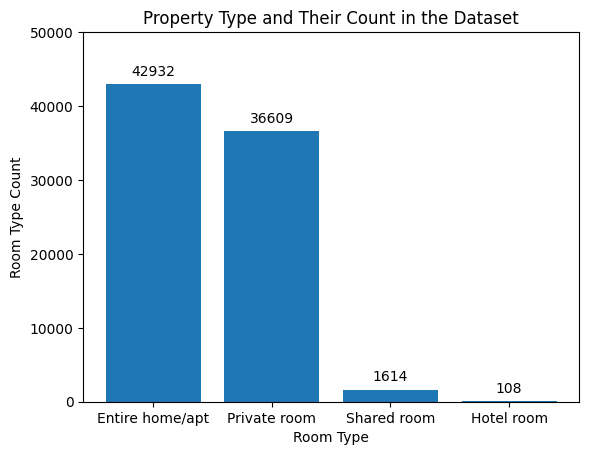

In [33]:
room_type_bar = plt.bar(property_types['room type'], property_types['count'])
plt.bar_label(room_type_bar, labels=property_types['count'], padding=4)
plt.ylim(0, 50000)
plt.xlabel('Room Type')
plt.ylabel('Room Type Count')
plt.title('Property Type and Their Count in the Dataset')
plt.show()

In [36]:
hood_group = df['neighbourhood group'].value_counts().to_frame().reset_index()
hood_group

,neighbourhood group,count
0,Brooklyn,33722
1,Manhattan,33547
2,Queens,10948
3,Bronx,2241
4,Staten Island,805


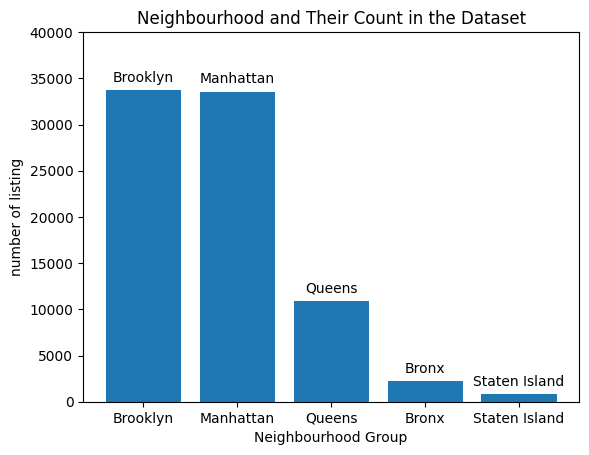

In [41]:
hood_group_bar = plt.bar(hood_group['neighbourhood group'], hood_group.loc[:,"count"])
plt.bar_label(hood_group_bar, labels=hood_group['neighbourhood group'], padding=4)
plt.ylim(0, 40000)
plt.xlabel('Neighbourhood Group')
plt.ylabel('number of listing')
plt.title('Neighbourhood and Their Count in the Dataset')
plt.show()

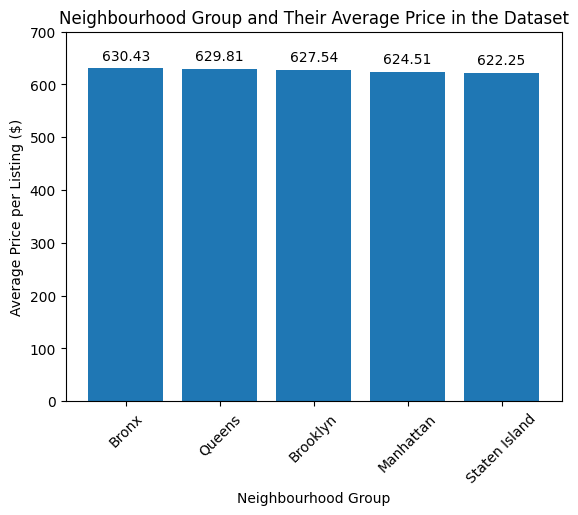

In [43]:
avg_price = df.groupby('neighbourhood group')['$price'].mean().sort_values(ascending=False).to_frame().reset_index()
avg_price_bar = plt.bar(avg_price['neighbourhood group'], avg_price['$price'])
plt.bar_label(avg_price_bar, labels=[f"{x:.2f}" for x in avg_price['$price']], label_type='edge', padding=4)
plt.ylim(0, 700)
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price per Listing ($)')
plt.xticks(rotation=45)
plt.title('Neighbourhood Group and Their Average Price in the Dataset')
plt.show()


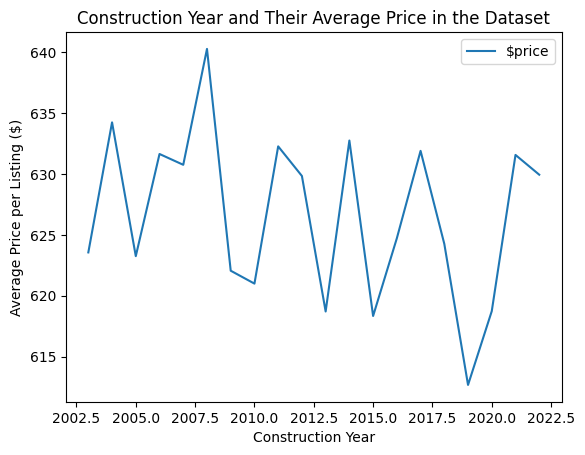

In [44]:
df.groupby(df['Construction year'])['$price'].mean().to_frame().plot();
plt.xlabel('Construction Year')
plt.ylabel('Average Price per Listing ($)')
plt.title('Construction Year and Their Average Price in the Dataset')
plt.show()

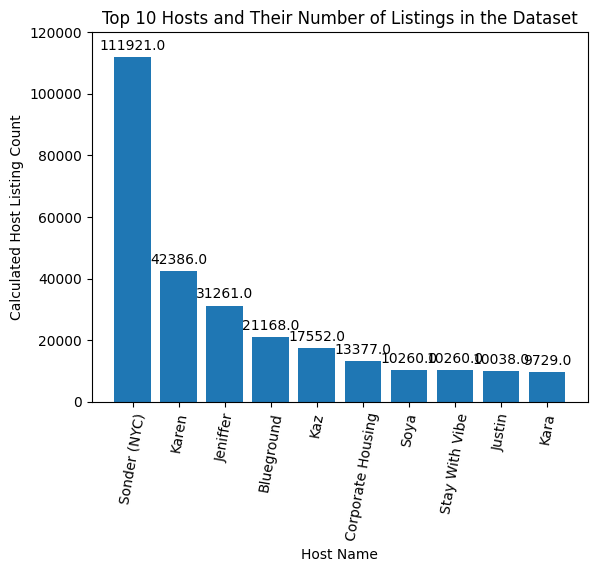

In [47]:
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending=False).nlargest(10).to_frame().reset_index()
hosts_bar = plt.bar(hosts['host name'], hosts['calculated host listings count'])
plt.bar_label(hosts_bar, labels=hosts['calculated host listings count'], label_type='edge', padding=3)
plt.xlabel('Host Name')
plt.ylabel('Calculated Host Listing Count')
plt.xticks(rotation=80)
plt.title('Top 10 Hosts and Their Number of Listings in the Dataset')
plt.ylim(0, 120000)
plt.show()


In [55]:
avg_rating = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending=False).to_frame().reset_index()
avg_rating


,host_identity_verified,review rate number
0,verified,3.289849
1,unconfirmed,3.282933


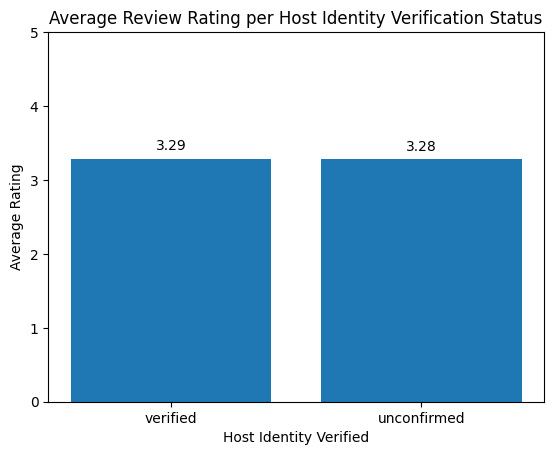

In [56]:
rating_bar = plt.bar(avg_rating['host_identity_verified'], avg_rating['review rate number'])

plt.bar_label(rating_bar, labels=[f"{x:.2f}" for x in avg_rating['review rate number']], padding=4)

plt.ylim(0, 5)
plt.xlabel('Host Identity Verified')
plt.ylabel('Average Rating')
plt.title('Average Review Rating per Host Identity Verification Status')
plt.show()


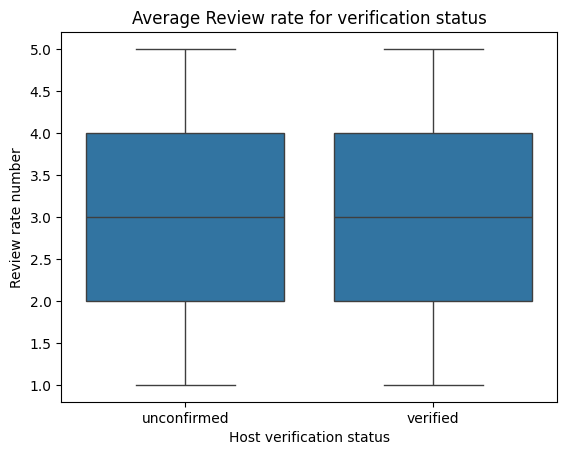

In [60]:
base_color = sns.color_palette()[0]
sns.boxplot(data= df, x="host_identity_verified", y = "review rate number", color= base_color);
plt.xlabel('Host verification status')
plt.ylabel('Review rate number')
plt.title('Average Review rate for verification status')
plt.show()

In [61]:
df['$price'].corr(df['$service fee'])


np.float64(0.9999908997036285)

Text(0.5, 1.0, 'A Regression plot showing the correlation of the price of a listing and its service fee')

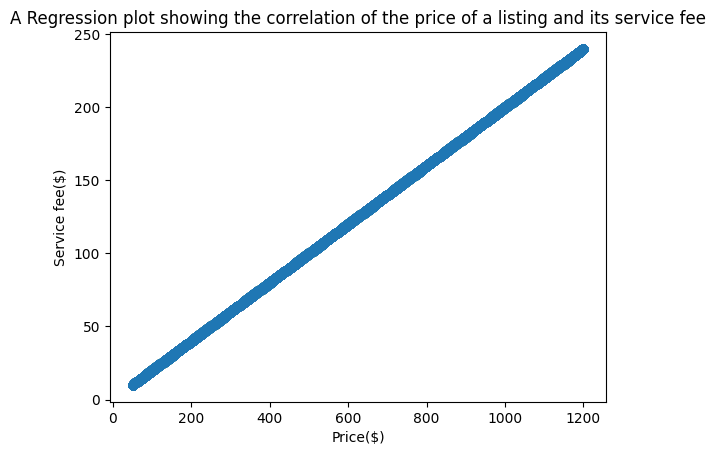

In [62]:
sns.regplot(df,x='$price', y='$service fee')

plt.xlabel('Price($)')
plt.ylabel('Service fee($)')
plt.title('A Regression plot showing the correlation of the price of a listing and its service fee')

In [64]:
ARRN = df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.378190
                    Private room               3.315789
                    Shared room                3.356322
Brooklyn            Entire home/apt            3.251608
                    Hotel room                 3.833333
                    Private room               3.283526
                    Shared room                3.327759
Manhattan           Entire home/apt            3.274865
                    Hotel room                 3.500000
                    Private room               3.293528
                    Shared room                3.269350
Queens              Entire home/apt            3.358646
                    Hotel room                 3.750000
                    Private room               3.317546
                    Shared room                3.326087
Staten Island       Entire home/apt            3.326877
                    Private room               3.490909
                    Shared room                3.714286

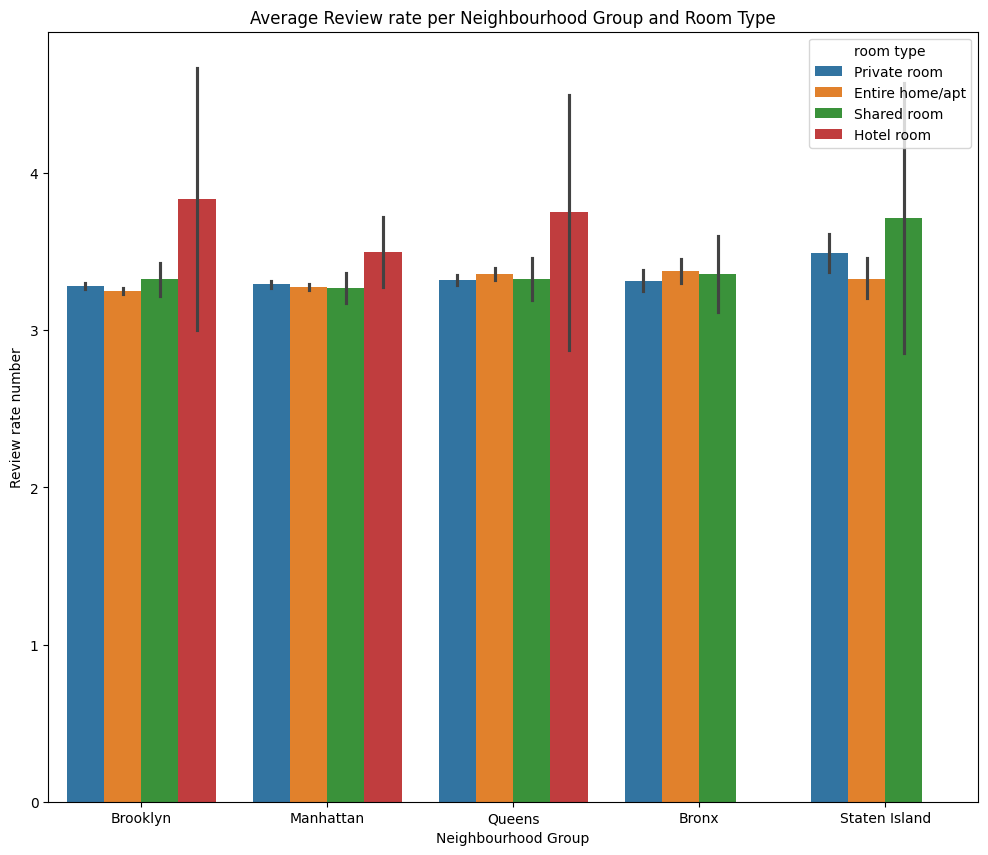

In [65]:
plt.figure(figsize=[12,10])
sns.barplot(data=df, x='neighbourhood group', y='review rate number', hue='room type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Review rate number')
plt.title('Average Review rate per Neighbourhood Group and Room Type')
plt.show()

Text(0.5, 1.0, 'A Regression plot showing the correlation of the calculated host listing count and its availability')

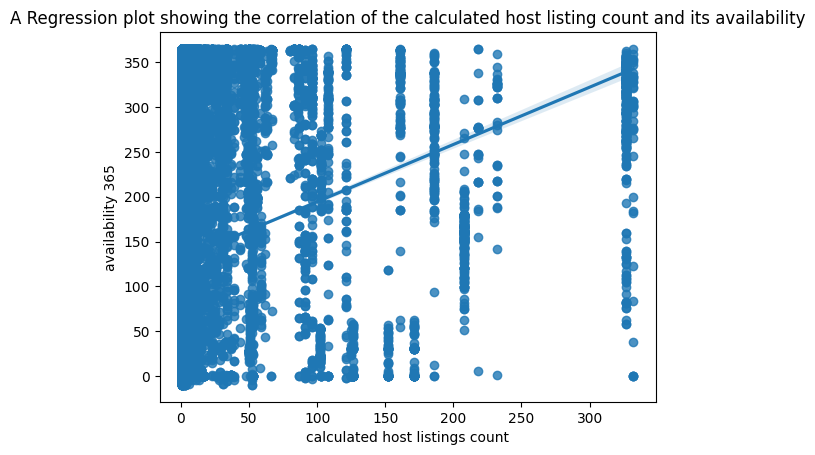

In [67]:
sns.regplot(df, x= 'calculated host listings count', y='availability 365')
plt.xlabel=('Calcuated hosts listings')
plt.ylabel=('Availability 365')
plt.title('A Regression plot showing the correlation of the calculated host listing count and its availability')

In [69]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.14856264998419236)

**Conclusion**

The analysis of the Airbnb dataset provided valuable insights into host behavior, pricing strategies, and guest preferences. Data cleaning steps such as handling missing values, removing duplicates, and standardizing formats ensured the dataset was reliable for analysis.

Key findings include:

- Room Type Trends: Entire homes/apartments dominate the listings, while shared rooms are the least preferred.

- Neighbourhood Insights: Certain neighbourhood groups have higher listing counts and higher average prices, showing demand concentration in popular areas.

- Host Activity: A small number of hosts manage a disproportionately large number of listings, indicating the presence of professional hosts.

- Pricing: Average prices vary significantly across neighbourhood groups, suggesting location is a major factor in pricing strategy.

- Reviews & Ratings: Verified hosts tend to have slightly higher average ratings and reviews, reinforcing the importance of trust and credibility in the platform.

Overall, the project highlights that location, verification status, and host professionalism play a significant role in shaping guest booking behavior. These insights can be useful for both prospective hosts aiming to optimize their listings and for Airbnb in refining its platform policies.

## Future Scope

1. **Price Prediction Models**: Use machine learning algorithms to predict optimal listing prices based on features like location, room type, availability, and host experience. This can help hosts maximize occupancy and revenue.

2. **Demand Forecasting**: Analyze seasonal trends and booking patterns to forecast demand in different neighbourhoods. This can assist Airbnb and hosts in preparing for peak seasons.

3. **Recommendation Systems**: Develop personalized recommendations for guests based on past bookings, preferences, and reviews to improve user experience.

4. **Sentiment Analysis on Reviews**: Apply Natural Language Processing (NLP) to analyze guest reviews and identify common complaints or highlights, helping hosts improve their services.

5. **Anomaly Detection**: Detect unusual pricing, fraudulent listings, or fake reviews using statistical or ML-based anomaly detection techniques.

6. **Geospatial Analysis**: Use mapping and clustering techniques to identify underserved areas with high potential for new listings.

7. **Host Performance Analytics**: Track host behavior over time to identify top performers and provide actionable insights to improve overall platform quality.
